# EDA - Telco Customer Churn

## Tabla de contenidos

- [1. Contexto y objetivo](#1-contexto-y-objetivo)
- [2. Estructura del dataset](#2-estructura-del-dataset)
- [3. Calidad de datos](#3-calidad-de-datos)
- [4. Distribuciones univariadas](#4-distribuciones-univariadas)
- [5. Variable objetivo](#5-variable-objetivo)
- [6. Relaciones entre variables y target](#6-relaciones-entre-variables-y-target)
- [7. Data leakage](#7-data-leakage)
- [8. Hallazgos y conclusiones](#8-hallazgos-y-conclusiones)

---

## 1. Contexto y objetivo

**Contexto de negocio.** Una empresa de telecomunicaciones (Telco) quiere anticipar qué clientes están en riesgo de darse de baja (*churn*) para poder intervenir con retención antes de que ocurra. Adquirir un cliente nuevo cuesta varias veces más que retener uno existente, así que un modelo que priorice bien a quién contactar tiene impacto directo en ingresos.

**Dataset.** Telco Customer Churn — 7 043 clientes × 50 columnas, con datos demográficos, de contrato, de servicios contratados y de facturación. Versionado con DVC, remoto en DagsHub.

**Objetivo de este notebook.** Este es el EDA de la Fase 1 del proyecto — exploración pura, sin lógica de producción. El propósito es construir el entendimiento necesario para tomar decisiones informadas en las fases siguientes:

- **Fase 2 (features):** qué variables transformar, combinar o descartar.
- **Fase 3 (modelo):** qué tan desbalanceado está el target, qué métricas usar, qué features son candidatas a mayor poder predictivo.

Para eso recorremos: estructura del dataset → calidad de datos → distribuciones → variable objetivo → relación de cada variable con el target → columnas con *data leakage* → conclusiones.

A continuación, configuramos el entorno (imports y estilo de gráficos) y arrancamos con la estructura del dataset.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100

---

## 2. Estructura del dataset

Forma general del dataset: filas, columnas, tipos de dato y una primera mirada a los valores. Esto ancla el resto del análisis — por ejemplo, confirma cuántas columnas son numéricas vs. categóricas antes de decidir cómo tratarlas.

In [2]:
df = pd.read_csv("../data/raw/telco.csv")

df.head()

,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


In [3]:
df.tail()

,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
7038,2569-WGERO,Female,30,No,No,No,No,0,United States,California,...,0,1639.44,3039.53,5,Stayed,No,45,5306,NaN,NaN
7039,6840-RESVB,Male,38,No,No,Yes,Yes,2,United States,California,...,0,865.20,2807.47,3,Stayed,No,59,2140,NaN,NaN
7040,2234-XADUH,Female,30,No,No,Yes,Yes,2,United States,California,...,0,2135.52,9453.04,4,Stayed,No,71,5560,NaN,NaN
7041,4801-JZAZL,Female,32,No,No,Yes,Yes,2,United States,California,...,0,0.00,319.21,4,Stayed,No,59,2793,NaN,NaN
7042,3186-AJIEK,Male,44,No,No,No,No,0,United States,California,...,0,2043.36,8887.86,4,Stayed,No,38,5097,NaN,NaN


In [4]:
df.shape

(7043, 50)

In [5]:
df.describe()

,Age,Number of Dependents,Zip Code,Latitude,Longitude,Population,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Churn Score,CLTV
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,46.509726,0.468692,93486.070567,36.197455,-119.756684,22139.603294,1.951867,32.386767,22.958954,20.515405,64.761692,2280.381264,1.962182,6.860713,749.099262,3034.379056,3.244924,58.505040,4400.295755
std,16.750352,0.962802,1856.767505,2.468929,2.154425,21152.392837,3.001199,24.542061,15.448113,20.418940,30.090047,2266.220462,7.902614,25.104978,846.660055,2865.204542,1.201657,21.170031,1183.057152
min,19.000000,0.000000,90001.000000,32.555828,-124.301372,11.000000,0.000000,1.000000,0.000000,0.000000,18.250000,18.800000,0.000000,0.000000,0.000000,21.360000,1.000000,5.000000,2003.000000
25%,32.000000,0.000000,92101.000000,33.990646,-121.788090,2344.000000,0.000000,9.000000,9.210000,3.000000,35.500000,400.150000,0.000000,0.000000,70.545000,605.610000,3.000000,40.000000,3469.000000
50%,46.000000,0.000000,93518.000000,36.205465,-119.595293,17554.000000,0.000000,29.000000,22.890000,17.000000,70.350000,1394.550000,0.000000,0.000000,401.440000,2108.640000,3.000000,61.000000,4527.000000
75%,60.000000,0.000000,95329.000000,38.161321,-117.969795,36125.000000,3.000000,55.000000,36.395000,27.000000,89.850000,3786.600000,0.000000,0.000000,1191.100000,4801.145000,4.000000,75.500000,5380.500000
max,80.000000,9.000000,96150.000000,41.962127,-114.192901,105285.000000,11.000000,72.000000,49.990000,85.000000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000,5.000000,96.000000,6500.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 50 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Under 30                           7043 non-null   object 
 4   Senior Citizen                     7043 non-null   object 
 5   Married                            7043 non-null   object 
 6   Dependents                         7043 non-null   object 
 7   Number of Dependents               7043 non-null   int64  
 8   Country                            7043 non-null   object 
 9   State                              7043 non-null   object 
 10  City                               7043 non-null   object 
 11  Zip Code                           7043 non-null   int64

In [7]:
df.dtypes

Customer ID                           object
Gender                                object
Age                                    int64
Under 30                              object
Senior Citizen                        object
Married                               object
Dependents                            object
Number of Dependents                   int64
Country                               object
State                                 object
City                                  object
Zip Code                               int64
Latitude                             float64
Longitude                            float64
Population                             int64
Quarter                               object
Referred a Friend                     object
Number of Referrals                    int64
Tenure in Months                       int64
Offer                                 object
Phone Service                         object
Avg Monthly Long Distance Charges    float64
Multiple L

---

## 3. Calidad de datos

Revisión de valores nulos, duplicados y cardinalidad por columna. El objetivo es detectar problemas que exijan limpieza o imputación antes de pasar a Fase 2.

In [8]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"count": missing, "pct (%)": missing_pct})
missing_df = missing_df[missing_df["count"] > 0].sort_values("count", ascending=False)

missing_df

,count,pct (%)
Churn Reason,5174,73.46
Churn Category,5174,73.46
Offer,3877,55.05
Internet Type,1526,21.67


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df["Customer ID"].duplicated().sum()

np.int64(0)

In [11]:
df.nunique()

Customer ID                          7043
Gender                                  2
Age                                    62
Under 30                                2
Senior Citizen                          2
Married                                 2
Dependents                              2
Number of Dependents                   10
Country                                 1
State                                   1
City                                 1106
Zip Code                             1626
Latitude                             1626
Longitude                            1625
Population                           1569
Quarter                                 1
Referred a Friend                       2
Number of Referrals                    12
Tenure in Months                       72
Offer                                   5
Phone Service                           2
Avg Monthly Long Distance Charges    3584
Multiple Lines                          2
Internet Service                  

---

## 4. Distribuciones univariadas

Forma de cada variable por separado — sesgo, dispersión, outliers y categorías dominantes — antes de cruzarlas con el target en la sección 6. Empezamos con el resumen numérico ya visto en la sección 2 (aquí como referencia rápida) y lo complementamos con histogramas y conteos.

In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,7043.0,46.509726,16.750352,19.000000,32.000000,46.000000,60.000000,80.000000
Number of Dependents,7043.0,0.468692,0.962802,0.000000,0.000000,0.000000,0.000000,9.000000
Zip Code,7043.0,93486.070567,1856.767505,90001.000000,92101.000000,93518.000000,95329.000000,96150.000000
Latitude,7043.0,36.197455,2.468929,32.555828,33.990646,36.205465,38.161321,41.962127
Longitude,7043.0,-119.756684,2.154425,-124.301372,-121.788090,-119.595293,-117.969795,-114.192901
Population,7043.0,22139.603294,21152.392837,11.000000,2344.000000,17554.000000,36125.000000,105285.000000
Number of Referrals,7043.0,1.951867,3.001199,0.000000,0.000000,0.000000,3.000000,11.000000
Tenure in Months,7043.0,32.386767,24.542061,1.000000,9.000000,29.000000,55.000000,72.000000
Avg Monthly Long Distance Charges,7043.0,22.958954,15.448113,0.000000,9.210000,22.890000,36.395000,49.990000
Avg Monthly GB Download,7043.0,20.515405,20.418940,0.000000,3.000000,17.000000,27.000000,85.000000


### 4.1 Variables numéricas

Histogramas de las variables numéricas con más relevancia de negocio (edad, antigüedad, cargos, CLTV, satisfacción, referidos).

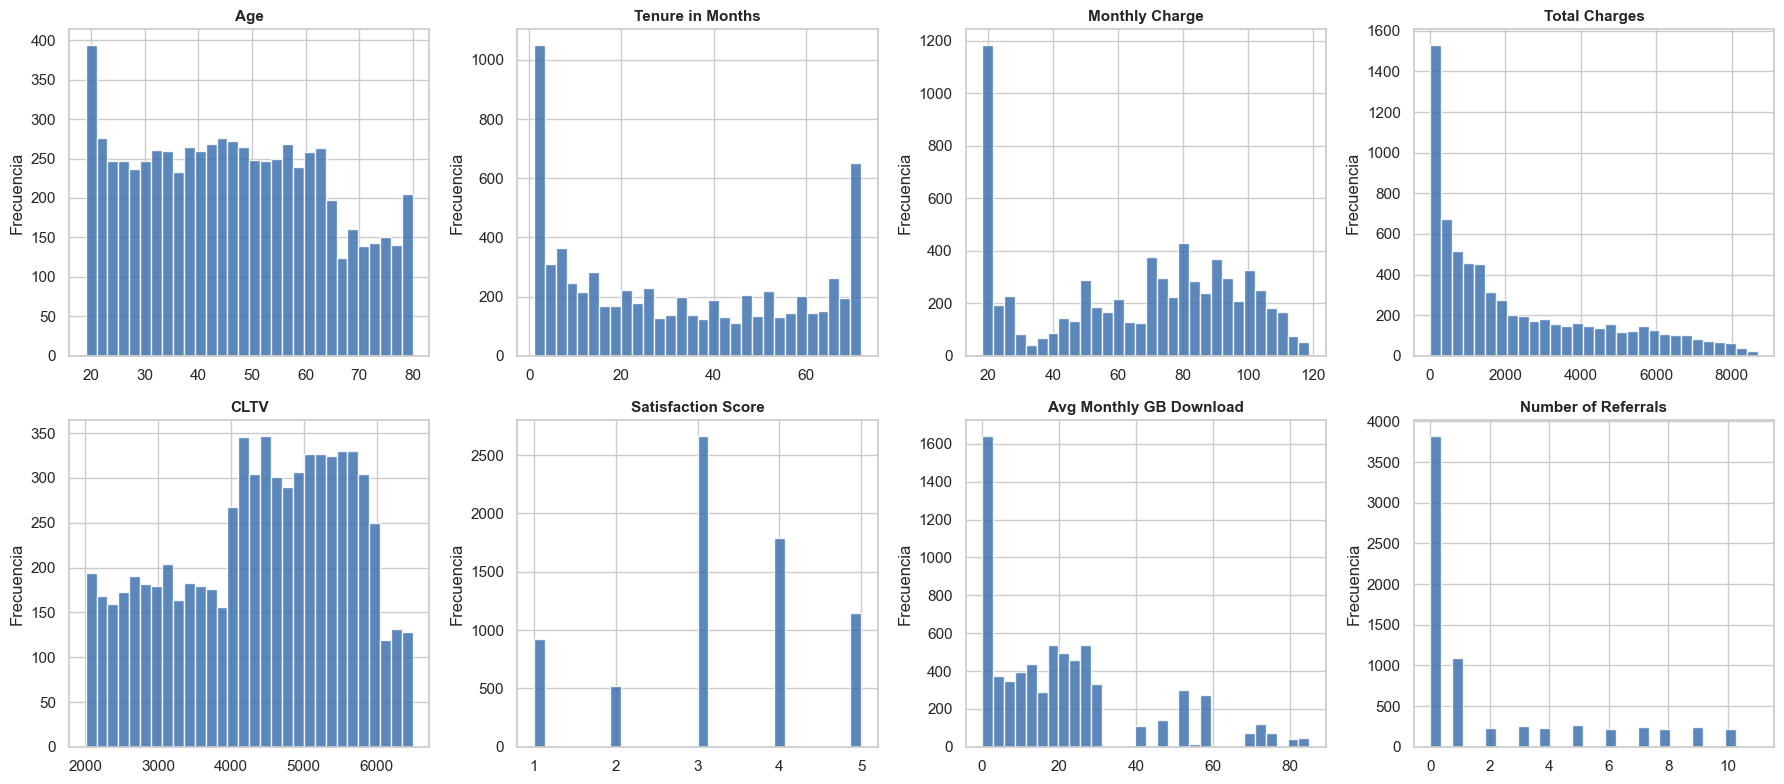

In [13]:
univariate_numeric = [
    "Age", "Tenure in Months", "Monthly Charge", "Total Charges",
    "CLTV", "Satisfaction Score", "Avg Monthly GB Download", "Number of Referrals",
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(univariate_numeric):
    axes[i].hist(df[col], bins=30, color="#3F72AF", alpha=0.85)
    axes[i].set_title(col, fontsize=11, fontweight="bold")
    axes[i].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

### 4.2 Variables categóricas

Conteo de clientes por categoría en las variables categóricas más relevantes para el negocio (demográficas, contrato y servicio).

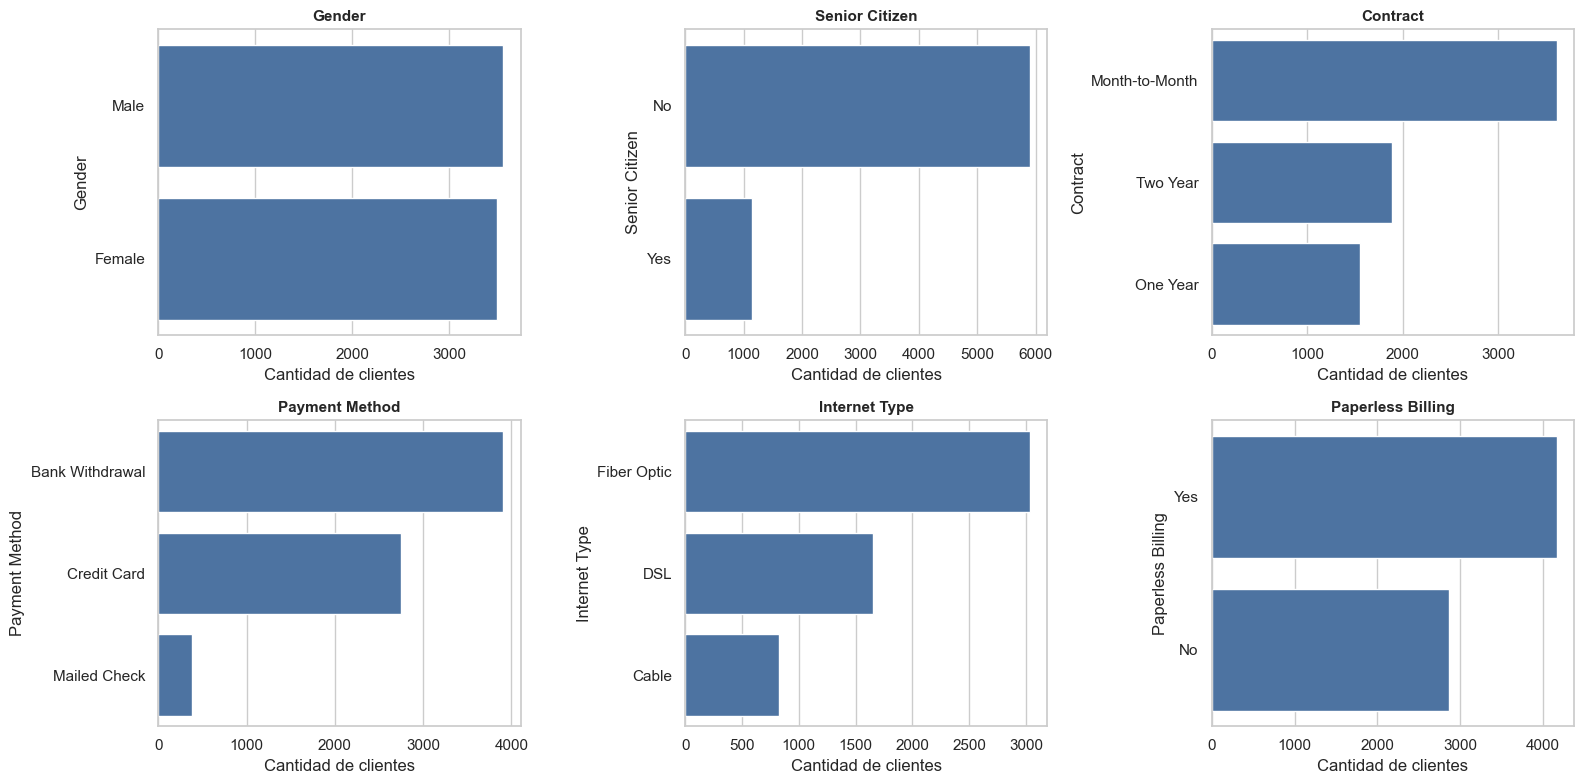

In [14]:
univariate_categorical = [
    "Gender", "Senior Citizen", "Contract", "Payment Method", "Internet Type", "Paperless Billing",
]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(univariate_categorical):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, color="#3F72AF", ax=axes[i])
    axes[i].set_title(col, fontsize=11, fontweight="bold")
    axes[i].set_xlabel("Cantidad de clientes")

plt.tight_layout()
plt.show()

---

## 5. Variable objetivo

`Churn Label` (Yes/No) es el target de clasificación binaria: si el cliente canceló el servicio en el trimestre. También miramos `Churn Reason` y `Churn Category` para entender el *por qué* de negocio detrás de los números, aunque esas columnas no puedan usarse como input del modelo (ver sección 7 — Data leakage).

C:\Users\Dereck\AppData\Local\Temp\ipykernel_6480\499065250.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_reasons.values, y=top_reasons.index, palette="Reds_r", ax=axes[1])
C:\Users\Dereck\AppData\Local\Temp\ipykernel_6480\499065250.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=categories.values, y=categories.index, palette="Oranges_r", ax=axes[2])


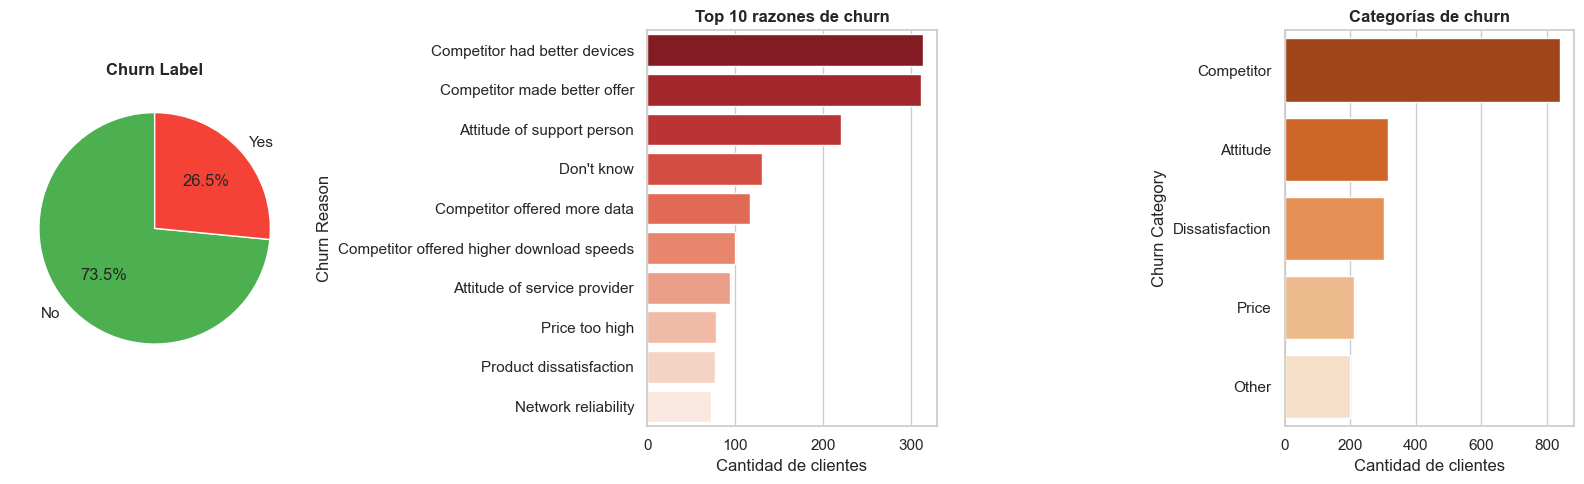


Tasa de churn global: 26.5%
Ratio No churn : Churn = 2.8 : 1

→ Dataset moderadamente desbalanceado.
→ Usar stratified cross-validation y métricas Precision-Recall/F1, no accuracy.


In [15]:
churn_counts = df["Churn Label"].value_counts()
churn_pct = (churn_counts / len(df) * 100).round(1)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Distribución general
colors = ["#4CAF50", "#F44336"]
axes[0].pie(
    churn_counts, labels=churn_counts.index,
    autopct="%1.1f%%", colors=colors, startangle=90,
)
axes[0].set_title("Churn Label", fontsize=12, fontweight="bold")

# Top 10 razones de churn
top_reasons = df[df["Churn Label"] == "Yes"]["Churn Reason"].value_counts().head(10)
sns.barplot(x=top_reasons.values, y=top_reasons.index, palette="Reds_r", ax=axes[1])
axes[1].set_title("Top 10 razones de churn", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Cantidad de clientes")

# Categorías de churn
categories = df[df["Churn Label"] == "Yes"]["Churn Category"].value_counts()
sns.barplot(x=categories.values, y=categories.index, palette="Oranges_r", ax=axes[2])
axes[2].set_title("Categorías de churn", fontsize=12, fontweight="bold")
axes[2].set_xlabel("Cantidad de clientes")

plt.tight_layout()
plt.show()

print(f"\nTasa de churn global: {churn_pct['Yes']:.1f}%")
print(f"Ratio No churn : Churn = {churn_counts['No'] / churn_counts['Yes']:.1f} : 1")
print("\n→ Dataset moderadamente desbalanceado.")
print("→ Usar stratified cross-validation y métricas Precision-Recall/F1, no accuracy.")

---

## 6. Relaciones entre variables y target

Cómo se relaciona cada grupo de variables con `Churn Label`: contrato y plan, variables numéricas clave, correlación entre numéricas, y servicios adicionales. Esto es lo que orienta qué features priorizar en la Fase 2.

### 6.1 Churn vs. contrato y plan

Las features de tipo de contrato, método de pago y tipo de internet suelen ser los predictores más fuertes en datasets de churn de telecomunicaciones.

C:\Users\Dereck\AppData\Local\Temp\ipykernel_6480\148481323.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(
C:\Users\Dereck\AppData\Local\Temp\ipykernel_6480\148481323.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(
C:\Users\Dereck\AppData\Local\Temp\ipykernel_6480\148481323.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(
C:\Users\Dereck\AppData\Local\Temp\ipykernel_6480\148481323.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `

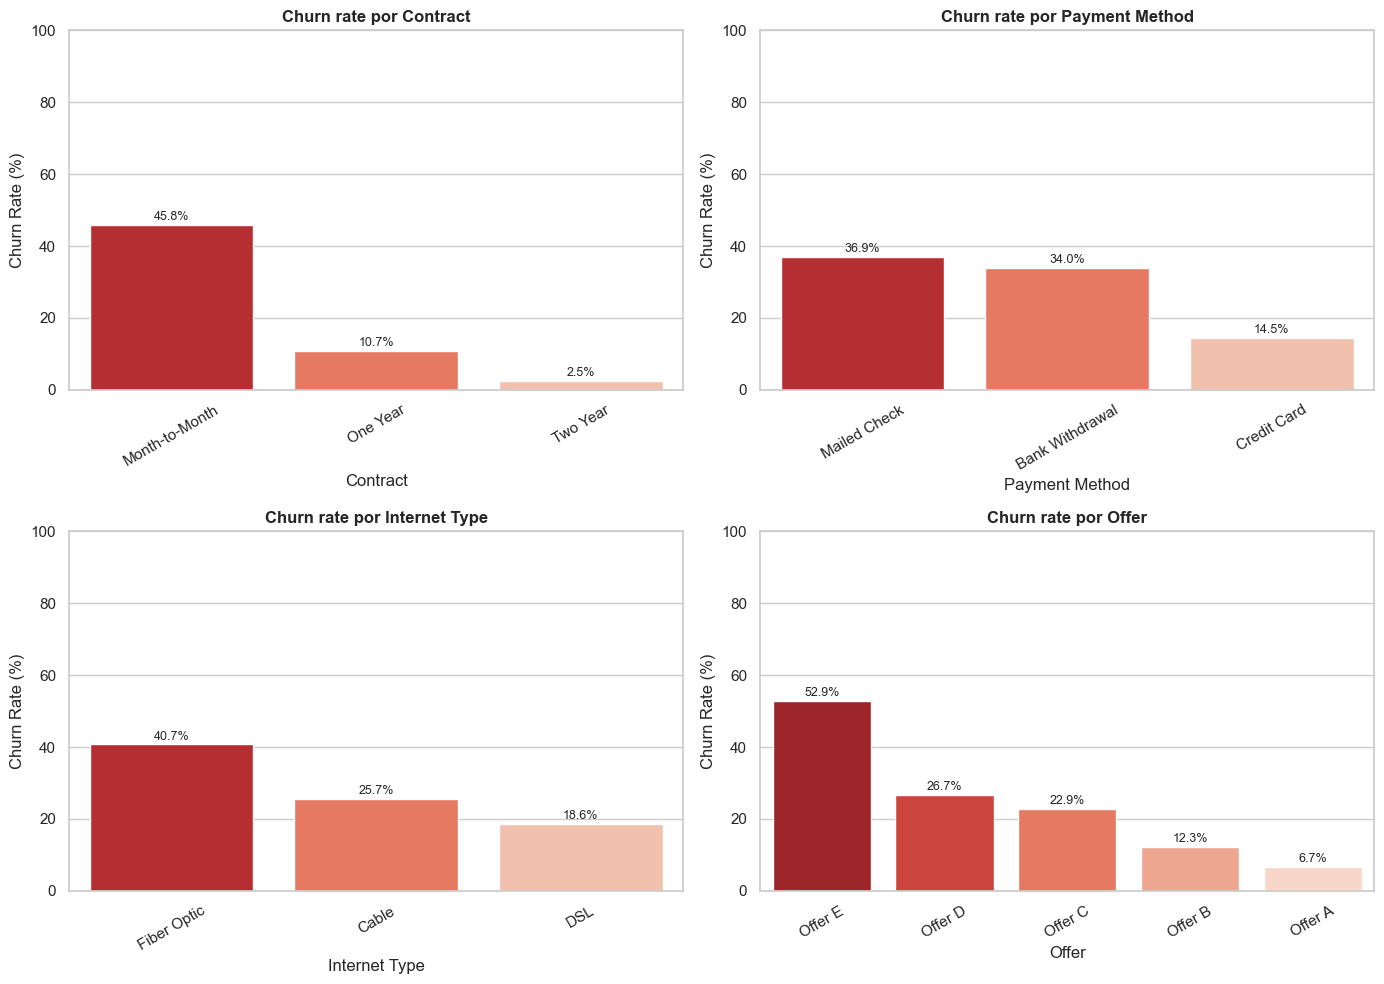

In [16]:
contract_features = ["Contract", "Payment Method", "Internet Type", "Offer"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feature in enumerate(contract_features):
    churn_rate = (
        df.groupby(feature)["Churn Label"]
        .apply(lambda x: (x == "Yes").mean() * 100)
        .sort_values(ascending=False)
        .reset_index(name="Churn Rate (%)")
    )
    bars = sns.barplot(
        data=churn_rate, x=feature, y="Churn Rate (%)",
        palette="Reds_r", ax=axes[i],
    )
    axes[i].set_title(f"Churn rate por {feature}", fontsize=12, fontweight="bold")
    axes[i].set_ylim(0, 100)
    axes[i].tick_params(axis="x", rotation=30)
    for bar in axes[i].patches:
        h = bar.get_height()
        axes[i].text(
            bar.get_x() + bar.get_width() / 2, h + 0.5,
            f"{h:.1f}%", ha="center", va="bottom", fontsize=9,
        )

plt.tight_layout()
plt.show()

### 6.2 Churn vs. features numéricas clave

Distribución de tenure, cargos y CLTV separando clientes churned vs. stayed. Las diferencias en medianas señalan features de alta discriminación.

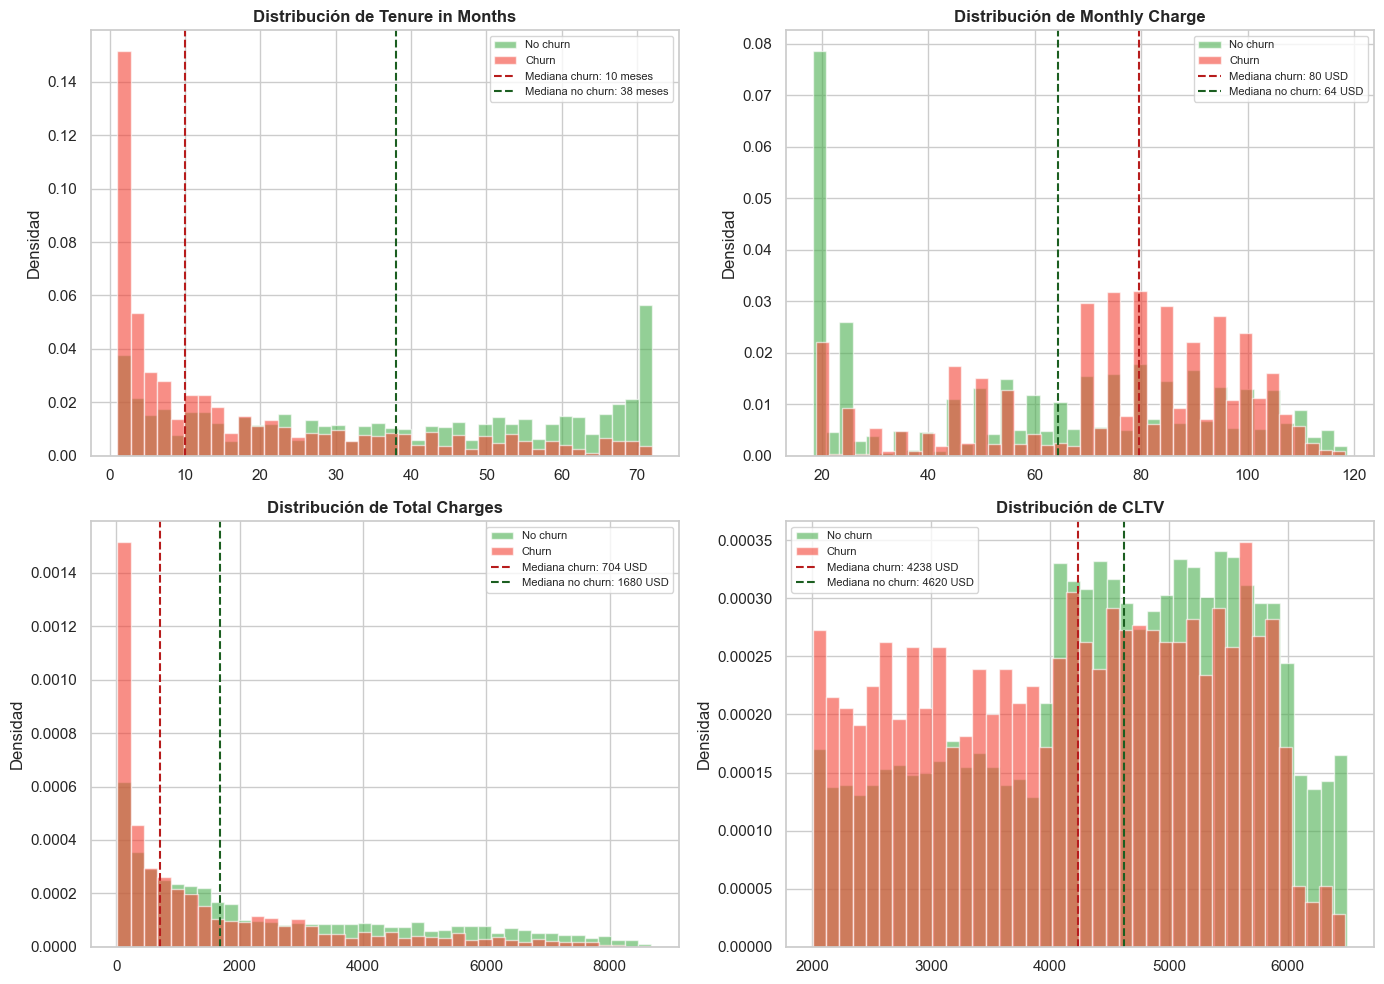

In [17]:
numeric_features = [
    ("Tenure in Months", "meses"),
    ("Monthly Charge", "USD"),
    ("Total Charges", "USD"),
    ("CLTV", "USD"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (feature, unit) in enumerate(numeric_features):
    churned = df[df["Churn Label"] == "Yes"][feature]
    stayed = df[df["Churn Label"] == "No"][feature]

    axes[i].hist(stayed, bins=40, alpha=0.6, label="No churn", color="#4CAF50", density=True)
    axes[i].hist(churned, bins=40, alpha=0.6, label="Churn", color="#F44336", density=True)
    axes[i].axvline(
        churned.median(), color="#B71C1C", linestyle="--", linewidth=1.5,
        label=f"Mediana churn: {churned.median():.0f} {unit}",
    )
    axes[i].axvline(
        stayed.median(), color="#1B5E20", linestyle="--", linewidth=1.5,
        label=f"Mediana no churn: {stayed.median():.0f} {unit}",
    )
    axes[i].set_title(f"Distribución de {feature}", fontsize=12, fontweight="bold")
    axes[i].set_ylabel("Densidad")
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()

### 6.3 Matriz de correlación (features numéricas)

Detecta multicolinealidad alta que afectaría principalmente al baseline de Regresión Logística (los modelos de árboles son robustos a esto).

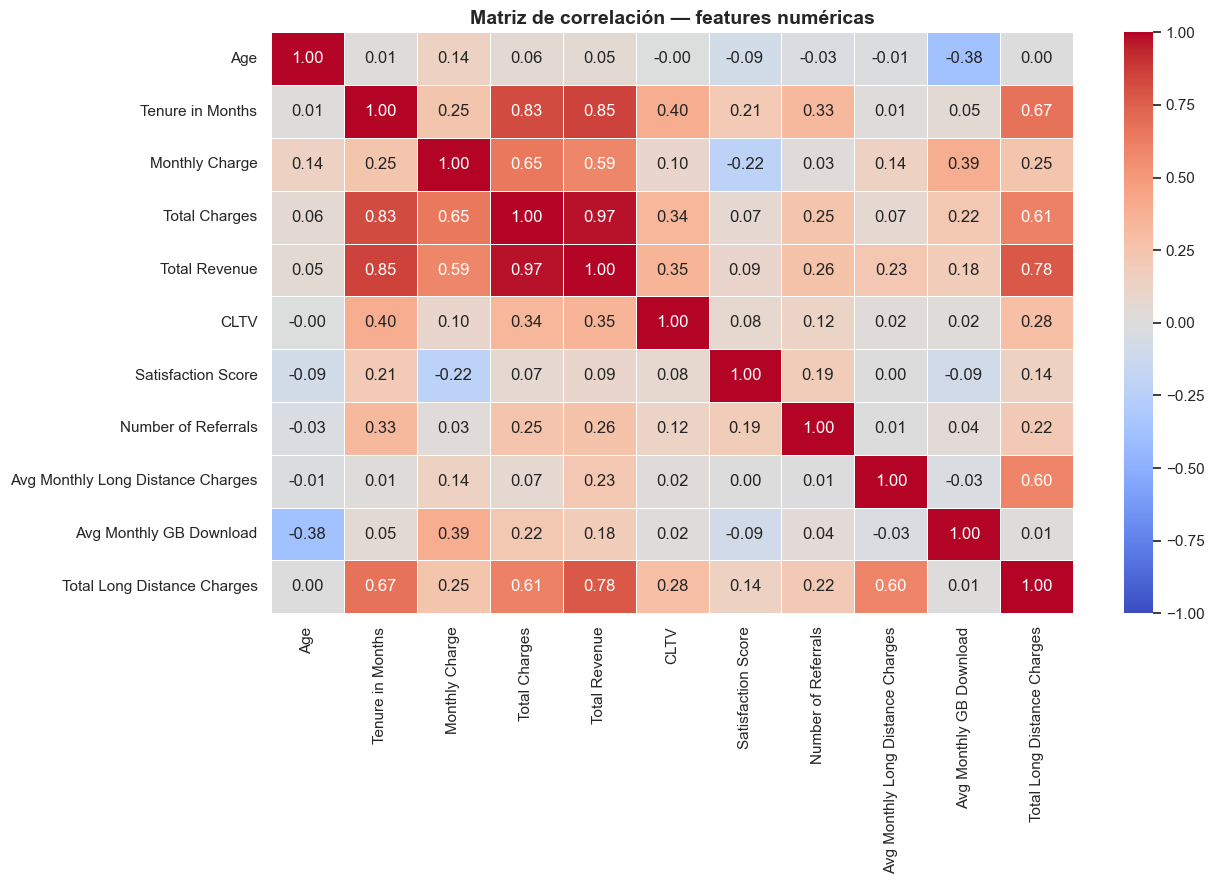

In [18]:
numeric_cols = [
    "Age", "Tenure in Months", "Monthly Charge", "Total Charges",
    "Total Revenue", "CLTV", "Satisfaction Score", "Number of Referrals",
    "Avg Monthly Long Distance Charges", "Avg Monthly GB Download",
    "Total Long Distance Charges",
]

corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(13, 9))
#mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    #mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Matriz de correlación — features numéricas", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 6.4 Features de servicio adicional

¿Los clientes que contratan servicios de valor agregado churnean menos? La hipótesis es que mayor "stickiness" de servicios reduce la probabilidad de cancelación.

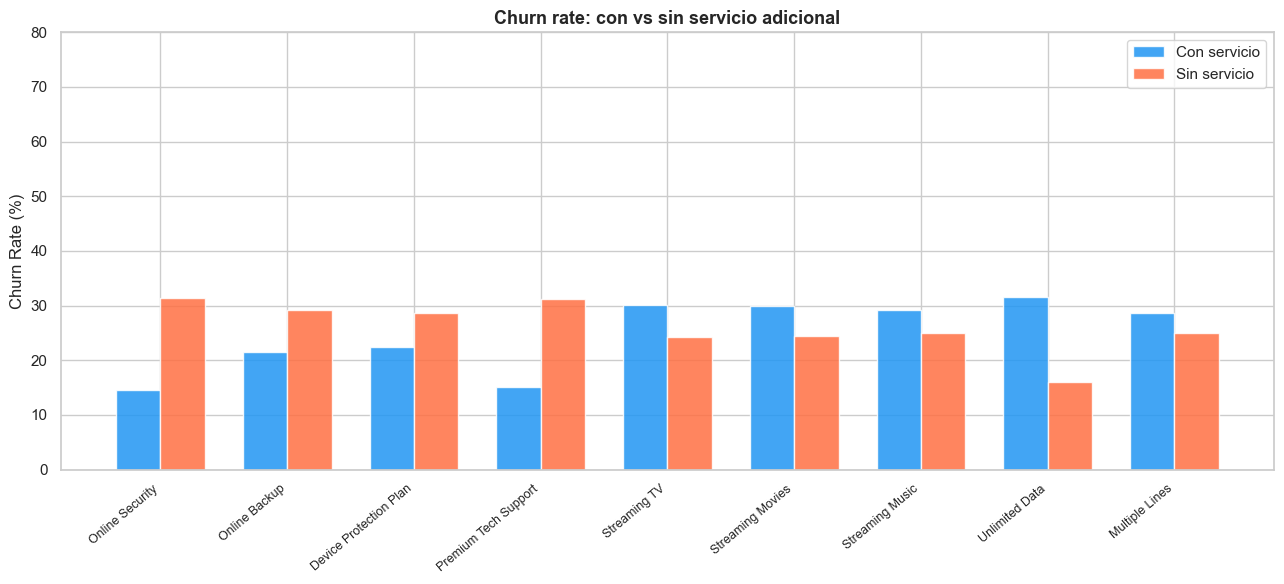

In [19]:
service_features = [
    "Online Security", "Online Backup", "Device Protection Plan",
    "Premium Tech Support", "Streaming TV", "Streaming Movies",
    "Streaming Music", "Unlimited Data", "Multiple Lines",
]

records = []
for feature in service_features:
    for val in ["Yes", "No"]:
        subset = df[df[feature] == val]
        if len(subset) > 0:
            rate = subset["Churn Label"].eq("Yes").mean() * 100
            records.append({"Servicio": feature, "Estado": val, "Churn Rate (%)": rate})

service_df = pd.DataFrame(records)

fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(service_features))
width = 0.35

yes_rates = service_df[service_df["Estado"] == "Yes"].set_index("Servicio").reindex(service_features)["Churn Rate (%)"]
no_rates = service_df[service_df["Estado"] == "No"].set_index("Servicio").reindex(service_features)["Churn Rate (%)"]

ax.bar(x - width / 2, yes_rates, width, label="Con servicio", color="#2196F3", alpha=0.85)
ax.bar(x + width / 2, no_rates, width, label="Sin servicio", color="#FF7043", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(service_features, rotation=40, ha="right", fontsize=9)
ax.set_ylabel("Churn Rate (%)")
ax.set_ylim(0, 80)
ax.set_title("Churn rate: con vs sin servicio adicional", fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

---

## 7. Data leakage

Algunas columnas del dataset están calculadas *a partir* del churn, o solo existen *después* de que el churn ya ocurrió. Si se usan como input del modelo, este aprendería a copiar la respuesta en vez de predecirla: funcionaría perfecto en entrenamiento y fallaría en producción, donde esos datos todavía no existen para un cliente activo.

| Columna | Por qué es leakage |
|---|---|
| `Churn Score` | Score de propensión a churn calculado por la empresa — ya es casi la predicción. |
| `Customer Status` | Incluye directamente el valor "Churned" — es el target codificado de otra forma. |
| `Churn Category` | Solo tiene valor para clientes que ya se dieron de baja (1 869 de 7 043 filas). |
| `Churn Reason` | Igual que `Churn Category`: solo existe post-churn. |

**Regla aplicada:** estas cuatro columnas se excluyen del feature set en la Fase 2. `Churn Label` es el único target.

---

## 8. Hallazgos y conclusiones

Insights clave para las decisiones de feature engineering (Fase 2):

### Desbalance del target
- **~26.5% de churn** — dataset moderadamente desbalanceado.
- Usar **cross-validation estratificada** en toda la Fase 3.
- Métricas principales: **Precision-Recall / F1**, no accuracy. Un modelo que predice "No churn" siempre tiene ~73.5% de accuracy sin aprender nada.

### Features de mayor poder predictivo esperado
1. **Contract** — contratos mes a mes tienen churn ~45%, anuales <10%. Feature de alto impacto.
2. **Tenure in Months** — clientes que churnean tienen tenure significativamente menor. Candidato a `is_new_customer` (tenure < 12 meses).
3. **Monthly Charge** — clientes que churnean pagan más en promedio. Posible interacción con `Contract`.
4. **Online Security / Premium Tech Support / Device Protection** — clientes SIN estos servicios churnean más. Candidatos a features binarias o a un feature de conteo de servicios.
5. **Payment Method** — diferencias claras entre métodos; encoding ordinal o one-hot.

### Multicolinealidad alta — manejar en Regresión Logística
- `Total Charges` ≈ `Tenure in Months × Monthly Charge` → alta correlación. Usar una de las dos en el baseline logístico.
- `Total Revenue` ≈ redundante con `Total Charges`. Descartar.
- En modelos de árboles (XGBoost, LightGBM, CatBoost) la multicolinealidad **no es problema**.

### Otras features a excluir del modelo (no son leakage, pero aportan poco)
| Feature | Motivo |
|---|---|
| `Latitude`, `Longitude`, `Zip Code` | Baja señal, alto costo de encoding. |
| `CLTV` | Score calculado por la empresa, posiblemente derivado del target — tratar con la misma cautela que las columnas de la sección 7. |

> Las columnas con leakage real (`Churn Score`, `Customer Status`, `Churn Category`, `Churn Reason`) se detallan en la sección 7. La decisión de excluirlas queda registrada en [`docs/decisions/0006-exclusion-de-columnas-por-data-leakage.md`](../docs/decisions/0006-exclusion-de-columnas-por-data-leakage.md).

### Valores nulos
- No hay valores nulos "accidentales": los NaN en `Offer`, `Internet Type`, `Churn Category` y `Churn Reason` son estructurales (por ejemplo, `Internet Type` es NaN cuando el cliente no tiene `Internet Service`). No se necesita estrategia de imputación, solo tenerlos en cuenta al construir features.